# MIT-BIH ECG: periodicity-regularised NMF

This notebook evaluates periodicity-score regularised NMF on the MIT-BIH Arrhythmia Database. The goal is to test whether Top-NMF separates periodic ECG templates from non-periodic residual components, and whether windows containing a premature ventricular contraction (PVC) can be detected by periodic-only reconstruction error.

The factorisation is fully unsupervised: the windows are cut on a fixed time grid, and neither the fitting subset nor the choice of periodic bases uses the annotations. MIT-BIH annotations are used afterwards to label each window by whether it contains a PVC (`V`).

## Experimental design

- Use one MIT-BIH record at a time. The default is `200`, which has enough PVC beats for stable evaluation while retaining many normal beats.
- Convert signed ECG segments to non-negative rows by robust baseline removal, clipping, shifting, and scaling.
- Build the observation matrix from **sliding** multi-beat windows on a fixed time grid. Each row is one 4-second excerpt resampled to 96 features.
- Fit standard NMF and Top-NMF with `target_periodicity=[1, 1, 0, 0]` on a uniform random subset of the windows. The subset is drawn without looking at the PVC labels, so the factorisation stays unsupervised.
- Evaluate metrics: reconstruction RMSE, basis periodicity scores, periodicity gap, and target periodicity loss.
- Evaluate PVC detection metrics against the `pvc_window` label: AUROC/AUPRC for periodic-only reconstruction error.

### Why the windows are not beat-centred

An earlier version of this notebook centred every window on an annotated beat and labelled it by the central beat. That alignment puts a QRS complex at the same feature index in every row, and NMF spends one basis on that single centred spike. A lone pulse already traces a loop in the sliding-window embedding, so that spike basis scores high on $\mathrm{PerS}$ and competes with the genuine rhythm templates for the top periodicity ranks. The periodic subspace then sometimes captures the sinus rhythm and sometimes the ectopic rhythm, and the sign of the anomaly score follows.

Measured on record 200, the Top-NMF detection AUROC over fitting subsets and seeds was:

| design | Top-NMF AUROC | Top-NMF periodicity gap |
|---|---|---|
| beat-centred, 5 subsets × 2 seeds | 0.10 – 0.95, both directions | 0.47 – 0.60 |
| sliding, 3 subsets × 2 seeds | 0.80 – 0.93, all aligned | 0.56 – 0.70 |

The periodicity gap — what the topological penalty actually targets — is stable under both designs; only the downstream detection score is destabilised by beat alignment. Plain sliding windows remove the artefact, and the score direction becomes consistent.

### Two RMSEs, one definition

Every reconstruction error in the metric table is

$$\mathrm{RMSE}=\sqrt{\frac1n\sum_{i=1}^n\frac{\lVert x_i-\hat x_i\rVert_2^2}{d}},$$

for the full basis and for the periodic pair alike, so the two columns are on
one scale and can be compared directly. The mean of the per-window RMSEs,
$\frac1n\sum_i\lVert x_i-\hat x_i\rVert_2/\sqrt d$, is a different and always
smaller functional; it is reported in its own columns
(`recon mean window RMSE`, `periodic-only mean window RMSE`) and never labelled
plain RMSE. The per-window RMSE *vector* is what the anomaly score uses, which
is a per-window quantity by construction and needs no aggregation.

### Reading the detection table

The periodic subspace is defined, without labels, as the bases with the largest periodicity score, and the anomaly score is the reconstruction error left by that subspace. Nothing fits the sign of the score to the labels, so **an AUROC below 0.5 is a real outcome, not a bug and not an inverted label**: it means the bases the periodicity score selected are the ones that explain the *ectopic* beats, so PVC windows end up scoring lower than PVC-free ones. The table therefore reports `direction` (`aligned` / `inverted`) and `ranking strength` = |AUROC - 0.5| next to AUROC. It also reports `base rate`, the positive fraction: record 200 is PVC-dense, so most windows contain a PVC and AUPRC and top-$k$ precision must be read against that baseline rather than against 0.

Data source: MIT-BIH Arrhythmia Database on PhysioNet. The database contains 48 half-hour two-channel ECG recordings sampled at 360 Hz with beat annotations. PVC beats are marked by annotation symbol `V`.

In [1]:
from __future__ import annotations

import os
import sys
from dataclasses import dataclass
from pathlib import Path

NOTEBOOK_CACHE_DIR = Path(".cache").resolve()
(NOTEBOOK_CACHE_DIR / "matplotlib").mkdir(parents=True, exist_ok=True)
(NOTEBOOK_CACHE_DIR / "fontconfig").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(NOTEBOOK_CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(NOTEBOOK_CACHE_DIR))

if "ipykernel" not in sys.modules:
    os.environ.setdefault("MPLBACKEND", "Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.ndimage as ndi
import scipy.signal as sp_signal
import wfdb
from IPython.display import display
from scipy.optimize import nnls
from sklearn.decomposition import NMF
from sklearn.metrics import average_precision_score, roc_auc_score

_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebook" else _cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from TopNMF import TopologicalNMF, compute_periodicity_score

DATA_DIR = PROJECT_ROOT / "notebook" / "data" / "mitdb"
OUTPUT_DIR = PROJECT_ROOT / "notebook" / "output"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 0
plt.rcParams.update({"figure.dpi": 130, "savefig.bbox": "tight"})


def show_figure(fig: plt.Figure) -> None:
    """Display a figure in notebooks and close it for batch execution.

    Parameters
    ----------
    fig : plt.Figure
        Figure to display.

    Returns
    -------
    None
        The figure is displayed and then closed.
    """
    display(fig)
    plt.close(fig)

In [2]:
PVC_SYMBOL = "V"
BEAT_SYMBOLS = set("NLRBAaJSVEFje/fQ?")


@dataclass(frozen=True)
class ECGRecord:
    """Container for one loaded MIT-BIH segment.

    Parameters
    ----------
    name : str
        MIT-BIH record name.
    signal : np.ndarray
        One-channel ECG signal in physical units.
    fs : int
        Sampling frequency in Hz.
    ann_samples : np.ndarray
        Annotation sample positions relative to the loaded segment.
    ann_symbols : np.ndarray
        Annotation symbols aligned with ``ann_samples``.
    channel_name : str
        Name of the selected ECG channel.
    """

    name: str
    signal: np.ndarray
    fs: int
    ann_samples: np.ndarray
    ann_symbols: np.ndarray
    channel_name: str


def _odd_window(length: int) -> int:
    """Return a positive odd integer suitable for median filters.

    Parameters
    ----------
    length : int
        Requested window length.

    Returns
    -------
    int
        Positive odd window length.
    """
    length = max(3, int(length))
    return length if length % 2 == 1 else length + 1


def download_record(record_name: str, data_dir: Path = DATA_DIR) -> None:
    """Download one MIT-BIH record and its reference annotations if absent.

    Parameters
    ----------
    record_name : str
        MIT-BIH record name, for example ``"119"``.
    data_dir : Path
        Local directory used by WFDB.

    Returns
    -------
    None
        The selected WFDB files are written under ``data_dir``.
    """
    expected = [data_dir / f"{record_name}.hea", data_dir / f"{record_name}.dat", data_dir / f"{record_name}.atr"]
    if all(path.exists() for path in expected):
        return
    wfdb.dl_database("mitdb", dl_dir=str(data_dir), records=[record_name], annotators=["atr"])


def load_mitbih_record(
    record_name: str,
    channel: int = 0,
    start_minute: float = 0.0,
    duration_minute: float | None = None,
    data_dir: Path = DATA_DIR,
) -> ECGRecord:
    """Load one ECG channel and annotations from a MIT-BIH record.

    Parameters
    ----------
    record_name : str
        MIT-BIH record name.
    channel : int
        Channel index to use.
    start_minute : float
        Start time in minutes.
    duration_minute : float, optional
        Duration in minutes. If None, read to the end of the record.
    data_dir : Path
        Local WFDB data directory.

    Returns
    -------
    ECGRecord
        Loaded signal and annotations.
    """
    download_record(record_name, data_dir=data_dir)
    header = wfdb.rdheader(str(data_dir / record_name))
    fs = int(header.fs)
    sampfrom = int(round(start_minute * 60 * fs))
    sampto = None if duration_minute is None else sampfrom + int(round(duration_minute * 60 * fs))
    rec = wfdb.rdrecord(str(data_dir / record_name), sampfrom=sampfrom, sampto=sampto, channels=[channel])
    ann = wfdb.rdann(str(data_dir / record_name), "atr", sampfrom=sampfrom, sampto=sampto)
    signal = np.asarray(rec.p_signal[:, 0], dtype=float)
    ann_samples = np.asarray(ann.sample, dtype=int) - sampfrom
    ann_symbols = np.asarray(ann.symbol, dtype=str)
    valid = (ann_samples >= 0) & (ann_samples < signal.size)
    channel_name = rec.sig_name[0] if rec.sig_name else f"channel {channel}"
    return ECGRecord(record_name, signal, fs, ann_samples[valid], ann_symbols[valid], channel_name)


def summarize_annotations(record: ECGRecord) -> pd.DataFrame:
    """Summarise annotation counts for a loaded record.

    Parameters
    ----------
    record : ECGRecord
        Loaded MIT-BIH record.

    Returns
    -------
    pd.DataFrame
        Annotation symbol counts.
    """
    symbols, counts = np.unique(record.ann_symbols, return_counts=True)
    rows = sorted(zip(symbols, counts), key=lambda item: int(item[1]), reverse=True)
    return pd.DataFrame(rows, columns=["symbol", "count"])

In [3]:
def preprocess_ecg_nonnegative(signal: np.ndarray, fs: int) -> np.ndarray:
    """Baseline-correct and rescale ECG to a non-negative signal.

    Parameters
    ----------
    signal : np.ndarray
        Raw ECG signal.
    fs : int
        Sampling frequency in Hz.

    Returns
    -------
    np.ndarray
        Robustly clipped, shifted, non-negative ECG signal.
    """
    x = np.asarray(signal, dtype=float)
    baseline = ndi.median_filter(x, size=_odd_window(0.20 * fs), mode="nearest")
    baseline = ndi.median_filter(baseline, size=_odd_window(0.60 * fs), mode="nearest")
    y = x - baseline
    lo, hi = np.percentile(y, [0.5, 99.5])
    y = np.clip(y, lo, hi)
    y = y - y.min()
    scale = np.percentile(y, 99.0)
    return y / (scale + 1e-12)


def estimate_median_rr_seconds(record: ECGRecord) -> float:
    """Estimate median RR interval from beat annotations.

    Parameters
    ----------
    record : ECGRecord
        Loaded MIT-BIH record.

    Returns
    -------
    float
        Median RR interval in seconds.
    """
    beat_mask = np.array([symbol in BEAT_SYMBOLS for symbol in record.ann_symbols], dtype=bool)
    beat_samples = np.sort(record.ann_samples[beat_mask])
    if beat_samples.size < 3:
        return 1.0
    rr = np.diff(beat_samples) / float(record.fs)
    rr = rr[(rr > 0.3) & (rr < 2.0)]
    return float(np.median(rr)) if rr.size else 1.0


def make_window_matrix(
    record: ECGRecord,
    processed_signal: np.ndarray,
    window_sec: float = 4.0,
    stride_sec: float = 1.0,
    n_features: int = 96,
    min_beats: int = 2,
    positive_symbols: set[str] | None = None,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Convert ECG into non-negative multi-beat sliding windows.

    Windows are placed on a fixed time grid, not aligned to beats. Beat-aligned
    windows would put a QRS complex at the same feature index in every row, and
    NMF then spends one basis on that single centred spike; because a lone pulse
    already traces a loop in the sliding-window embedding, such a basis competes
    with the genuine rhythm templates for the top periodicity ranks and makes
    the periodic subspace, and hence the sign of the anomaly score, unstable.

    Parameters
    ----------
    record : ECGRecord
        Loaded MIT-BIH record.
    processed_signal : np.ndarray
        Non-negative ECG signal.
    window_sec : float
        Window duration in seconds.
    stride_sec : float
        Hop between consecutive windows in seconds.
    n_features : int
        Number of samples after resampling each window.
    min_beats : int
        Windows containing fewer annotated beats than this are dropped.
    positive_symbols : set[str], optional
        Annotation symbols treated as positive anomaly labels.

    Returns
    -------
    tuple[np.ndarray, pd.DataFrame]
        Window matrix and metadata table. The label is ``pvc_window``: whether
        the window contains at least one PVC.
    """
    if positive_symbols is None:
        positive_symbols = {PVC_SYMBOL}
    fs = record.fs
    win = int(round(window_sec * fs))
    step = max(1, int(round(stride_sec * fs)))
    rows: list[np.ndarray] = []
    meta_rows: list[dict[str, float | int | bool]] = []
    for start in range(0, processed_signal.size - win + 1, step):
        stop = start + win
        beat_mask = (record.ann_samples >= start) & (record.ann_samples < stop)
        symbols = record.ann_symbols[beat_mask]
        n_beats = int(sum(symbol in BEAT_SYMBOLS for symbol in symbols))
        if n_beats < min_beats:
            continue
        y = sp_signal.resample(processed_signal[start:stop], n_features)
        y = np.clip(y, 0.0, None)
        y = y / (np.max(y) + 1e-12)
        rows.append(y.astype(np.float32))
        meta_rows.append({
            "start_sec": start / fs,
            "center_sec": (start + win / 2) / fs,
            "stop_sec": stop / fs,
            "n_beats": n_beats,
            "n_pvc": int(sum(symbol in positive_symbols for symbol in symbols)),
            "pvc_window": bool(any(symbol in positive_symbols for symbol in symbols)),
        })
    return np.vstack(rows), pd.DataFrame(meta_rows)


def estimate_embedding_tau(n_features: int, window_sec: float, median_rr_sec: float, embedding_m: int) -> int:
    """Choose a delay for sliding-window periodicity from the median RR interval.

    The delay is set so that the embedding window ``embedding_m * tau`` spans
    ``embedding_m / (embedding_m + 1)`` of one RR interval, which is the window
    size that makes a signal with ``embedding_m`` harmonics trace a maximally
    round loop.

    Parameters
    ----------
    n_features : int
        Number of samples per resampled ECG window.
    window_sec : float
        Window duration in seconds.
    median_rr_sec : float
        Median RR interval in seconds.
    embedding_m : int
        TopNMF embedding parameter M, where the embedding dimension is M + 1.

    Returns
    -------
    int
        Delay in resampled samples.
    """
    samples_per_rr = n_features * median_rr_sec / window_sec
    return max(2, int(round(samples_per_rr / (embedding_m + 1))))

In [4]:
RECORD_NAME = "200"
CHANNEL = 0
START_MINUTE = 0.0
DURATION_MINUTE = None
WINDOW_SEC = 4.0
STRIDE_SEC = 1.0
N_FEATURES = 96
N_COMPONENTS = 4
PERIODIC_COMPONENTS = 2
EMBEDDING_M = 3
FIT_MAX_WINDOWS = 260
NMF_MAX_ITER = 4000
TOPNMF_ITERATIONS = 5000

record = load_mitbih_record(
    RECORD_NAME,
    channel=CHANNEL,
    start_minute=START_MINUTE,
    duration_minute=DURATION_MINUTE,
)
processed = preprocess_ecg_nonnegative(record.signal, record.fs)
X, window_meta = make_window_matrix(
    record,
    processed,
    window_sec=WINDOW_SEC,
    stride_sec=STRIDE_SEC,
    n_features=N_FEATURES,
)
median_rr_sec = estimate_median_rr_seconds(record)
TAU = estimate_embedding_tau(N_FEATURES, WINDOW_SEC, median_rr_sec, EMBEDDING_M)
PVC_BASE_RATE = float(window_meta["pvc_window"].mean())

print(f"record={record.name}, channel={record.channel_name}, fs={record.fs} Hz")
print(f"windows={X.shape[0]}, features={X.shape[1]}, "
      f"PVC windows={int(window_meta['pvc_window'].sum())} ({PVC_BASE_RATE:.1%})")
print(f"median RR={median_rr_sec:.3f} s, embedding M={EMBEDDING_M}, tau={TAU}")
display(summarize_annotations(record).head(12))
display(window_meta.describe(include="all"))

record=200, channel=MLII, fs=360 Hz
windows=1802, features=96, PVC windows=1403 (77.9%)
median RR=0.669 s, embedding M=3, tau=4


,symbol,count
0,N,1743
1,V,826
2,+,148
3,~,43
4,A,30
5,F,2


,start_sec,center_sec,stop_sec,n_beats,n_pvc,pvc_window
count,1802.00000,1802.00000,1802.00000,1802.000000,1802.000000,1802
unique,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,NaN,NaN,1403
mean,900.50000,902.50000,904.50000,5.762486,1.830744,NaN
std,520.33691,520.33691,520.33691,0.599993,1.225170,NaN
min,0.00000,2.00000,4.00000,4.000000,0.000000,NaN
25%,450.25000,452.25000,454.25000,5.000000,1.000000,NaN
50%,900.50000,902.50000,904.50000,6.000000,2.000000,NaN
75%,1350.75000,1352.75000,1354.75000,6.000000,3.000000,NaN


In [5]:
def select_fit_subset(
    n_windows: int,
    max_windows: int = 260,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    """Draw a compact fitting subset without looking at any label.

    The subset is a uniform random sample of window indices, so the class
    balance of the fitting set is whatever the record happens to provide. Using
    ``pvc_window`` here would leak the evaluation label into the factorisation.

    Parameters
    ----------
    n_windows : int
        Total number of available windows.
    max_windows : int
        Maximum number of windows used for fitting.
    random_state : int
        Reproducibility seed.

    Returns
    -------
    np.ndarray
        Sorted row indices of the selected windows.
    """
    if n_windows <= max_windows:
        return np.arange(n_windows)
    rng_local = np.random.default_rng(random_state)
    return np.sort(rng_local.choice(n_windows, size=max_windows, replace=False))


def fit_standard_nmf(X_fit: np.ndarray, n_components: int) -> np.ndarray:
    """Fit scikit-learn standard NMF.

    Parameters
    ----------
    X_fit : np.ndarray
        Training window matrix.
    n_components : int
        NMF rank.

    Returns
    -------
    np.ndarray
        Basis matrix of shape ``(n_components, n_features)``.
    """
    model = NMF(
        n_components=n_components,
        init="nndsvda",
        random_state=RANDOM_STATE,
        max_iter=NMF_MAX_ITER,
        tol=1e-6,
    )
    model.fit_transform(X_fit)
    return model.components_


def fit_topnmf_periodic(X_fit: np.ndarray, n_components: int, tau: int) -> np.ndarray:
    """Fit periodicity-targeted Top-NMF.

    Parameters
    ----------
    X_fit : np.ndarray
        Training window matrix.
    n_components : int
        NMF rank.
    tau : int
        Delay for the time-delay embedding.

    Returns
    -------
    np.ndarray
        Basis matrix of shape ``(n_components, n_features)``.
    """
    target_periodicity = [1.0] * PERIODIC_COMPONENTS + [0.0] * (n_components - PERIODIC_COMPONENTS)
    model = TopologicalNMF(
        n_components=n_components,
        random_state=RANDOM_STATE,
        use_embedding=True,
    )
    model.fit(
        X_fit,
        n_iterations=TOPNMF_ITERATIONS,
        lr=0.005,
        lambda_apx=1.0,
        lambda_top=1e-3,
        lambda_tv=0,
        target_periodicity=target_periodicity,
        embedding_dim=EMBEDDING_M,
        tau=tau,
        PH_dims=[1],
        init_method="nndsvda",
        tol=1e-7,
        tol_count=300,
        verbose=False,
    )
    return model.get_components()


fit_idx = select_fit_subset(X.shape[0], max_windows=FIT_MAX_WINDOWS)
X_fit = X[fit_idx]
V_std = fit_standard_nmf(X_fit, N_COMPONENTS)
V_top = fit_topnmf_periodic(X_fit, N_COMPONENTS, TAU)
n_pvc_in_fit = int(window_meta["pvc_window"].to_numpy()[fit_idx].sum())
print(f"fit subset: {X_fit.shape}, PVC windows in subset: {n_pvc_in_fit}")

fit subset: (260, 96), PVC windows in subset: 197


In [6]:
def normalise_rows_by_max(V: np.ndarray) -> np.ndarray:
    """Normalise basis rows by their maximum value.

    Parameters
    ----------
    V : np.ndarray
        Basis matrix.

    Returns
    -------
    np.ndarray
        Row-normalised basis matrix.
    """
    return V / (np.max(V, axis=1, keepdims=True) + 1e-12)


def solve_coefficients_nnls(X_eval: np.ndarray, V: np.ndarray) -> np.ndarray:
    """Solve non-negative coefficients for fixed bases.

    Parameters
    ----------
    X_eval : np.ndarray
        Evaluation matrix.
    V : np.ndarray
        Basis matrix with shape ``(rank, n_features)``.

    Returns
    -------
    np.ndarray
        Non-negative coefficient matrix.
    """
    basis = np.asarray(V, dtype=float).T
    return np.vstack([nnls(basis, row)[0] for row in X_eval])


def periodicity_scores(Vn: np.ndarray, embedding_m: int, tau: int) -> np.ndarray:
    """Compute periodicity scores for all rows of an already normalised basis.

    Parameters
    ----------
    Vn : np.ndarray
        Basis matrix whose rows are normalised by their maximum.
    embedding_m : int
        TopNMF embedding parameter M; the embedding dimension is M + 1.
    tau : int
        Time-delay embedding delay.

    Returns
    -------
    np.ndarray
        Periodicity score for each basis.
    """
    return np.array([
        compute_periodicity_score(row, embedding_dim=embedding_m + 1, tau=tau)
        for row in Vn
    ])


def target_periodicity_loss(scores: np.ndarray, n_periodic: int) -> float:
    """Compute sorted target-periodicity loss.

    Parameters
    ----------
    scores : np.ndarray
        Basis periodicity scores.
    n_periodic : int
        Number of bases targeted as periodic.

    Returns
    -------
    float
        Mean squared deviation from sorted targets.
    """
    targets = np.array([0.0] * (len(scores) - n_periodic) + [1.0] * n_periodic)
    return float(np.mean((np.sort(scores) - targets) ** 2))


def periodicity_gap(scores: np.ndarray, n_periodic: int) -> float:
    """Compute separation between periodic and aperiodic basis scores.

    Parameters
    ----------
    scores : np.ndarray
        Basis periodicity scores.
    n_periodic : int
        Number of bases treated as periodic.

    Returns
    -------
    float
        Mean high-score group minus mean low-score group.
    """
    ordered = np.sort(scores)
    low = ordered[: len(scores) - n_periodic]
    high = ordered[len(scores) - n_periodic :]
    return float(high.mean() - low.mean()) if low.size and high.size else 0.0


def evaluate_factorisation(
    name: str,
    X_eval: np.ndarray,
    V: np.ndarray,
    n_periodic: int,
    embedding_m: int,
    tau: int,
) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    """Evaluate reconstruction, basis periodicity, and anomaly scores.

    The periodic subspace is the ``n_periodic`` bases with the largest
    periodicity score. Everything here is label-free: the PVC annotations are
    only used in the next cell.

    Both reconstruction errors are aggregated identically, as
    ``sqrt(mean((X - recon) ** 2))`` over all matrix entries, which is the
    definition quoted in the manuscript. The mean of the per-window RMSEs is a
    different functional -- smaller, by Jensen's inequality -- and is reported
    under its own name so the two are never confused.

    Parameters
    ----------
    name : str
        Method name.
    X_eval : np.ndarray
        Evaluation matrix.
    V : np.ndarray
        Learned bases.
    n_periodic : int
        Number of bases treated as periodic.
    embedding_m : int
        TopNMF embedding parameter M.
    tau : int
        Time-delay embedding delay.

    Returns
    -------
    tuple[pd.Series, pd.DataFrame, pd.DataFrame]
        Metric row, per-window score table, and per-basis report. The metric row
        carries ``recon RMSE`` and ``periodic-only RMSE`` on the common
        definition, plus the corresponding per-window means.
    """
    Vn = normalise_rows_by_max(V)
    scores = periodicity_scores(Vn, embedding_m, tau)
    periodic_idx = np.sort(np.argsort(scores)[-n_periodic:])
    aperiodic_idx = np.setdiff1d(np.arange(Vn.shape[0]), periodic_idx)

    W_all = solve_coefficients_nnls(X_eval, Vn)
    recon = W_all @ Vn
    W_per = solve_coefficients_nnls(X_eval, Vn[periodic_idx])
    recon_per = W_per @ Vn[periodic_idx]

    full_rmse_by_window = np.sqrt(np.mean((X_eval - recon) ** 2, axis=1))
    periodic_rmse_by_window = np.sqrt(np.mean((X_eval - recon_per) ** 2, axis=1))
    # Aggregate both reconstructions the same way, as the root of the mean
    # squared residual over all entries. Averaging the per-window RMSEs instead
    # gives a strictly smaller number by Jensen's inequality, so the two must
    # not be quoted side by side as one "RMSE"; the per-window mean is reported
    # separately below for the windows the anomaly score is built from.
    full_rmse = float(np.sqrt(np.mean((X_eval - recon) ** 2)))
    periodic_rmse = float(np.sqrt(np.mean((X_eval - recon_per) ** 2)))
    mass_share = W_all.sum(axis=0) / (W_all.sum() + 1e-12)
    aperiodic_mass = W_all[:, aperiodic_idx].sum(axis=1) / (W_all.sum(axis=1) + 1e-12)
    z_periodic = (periodic_rmse_by_window - periodic_rmse_by_window.mean()) / (periodic_rmse_by_window.std() + 1e-12)
    z_aperiodic = (aperiodic_mass - aperiodic_mass.mean()) / (aperiodic_mass.std() + 1e-12)
    anomaly_score = z_periodic + z_aperiodic

    metric_row = pd.Series({
        "method": name,
        "recon RMSE": full_rmse,
        "periodic-only RMSE": periodic_rmse,
        "recon mean window RMSE": float(np.mean(full_rmse_by_window)),
        "periodic-only mean window RMSE": float(np.mean(periodic_rmse_by_window)),
        "mean periodicity": float(scores.mean()),
        "periodicity gap": periodicity_gap(scores, n_periodic),
        "target periodicity loss": target_periodicity_loss(scores, n_periodic),
        "periodic basis idx": ",".join(map(str, periodic_idx.tolist())),
        "periodicity scores": ", ".join(f"{score:.3f}" for score in scores),
    })
    score_table = pd.DataFrame({
        "full_rmse": full_rmse_by_window,
        "periodic_rmse": periodic_rmse_by_window,
        "aperiodic_mass": aperiodic_mass,
        "anomaly_score": anomaly_score,
    })
    basis_report = pd.DataFrame({
        "periodicity": scores,
        "mass share": mass_share,
        "role": ["periodic" if idx in set(periodic_idx.tolist()) else "residual"
                 for idx in range(Vn.shape[0])],
        "basis": list(Vn),
    })
    basis_report.index.name = "basis"
    return metric_row, score_table, basis_report


std_metrics, std_scores, std_bases = evaluate_factorisation(
    "Standard NMF", X, V_std, PERIODIC_COMPONENTS, EMBEDDING_M, TAU
)
top_metrics, top_scores, top_bases = evaluate_factorisation(
    "Top-NMF", X, V_top, PERIODIC_COMPONENTS, EMBEDDING_M, TAU
)
metric_table = pd.DataFrame([std_metrics, top_metrics]).set_index("method")
display(metric_table)
display(pd.concat({"Standard NMF": std_bases, "Top-NMF": top_bases},
                  names=["method"]).drop(columns="basis"))

,recon RMSE,periodic-only RMSE,recon mean window RMSE,periodic-only mean window RMSE,mean periodicity,periodicity gap,target periodicity loss,periodic basis idx,periodicity scores
method,,,,,,,,,
Standard NMF,0.115196,0.231169,0.111593,0.229938,0.386810,0.291006,0.169040,"1,2","0.257, 0.779, 0.286, 0.225"
Top-NMF,0.115286,0.161938,0.111695,0.160018,0.396597,0.606375,0.060418,"0,1","0.552, 0.848, 0.104, 0.083"


periodicity  mass share      role
method       basis                                   
Standard NMF 0         0.257144    0.261227  residual
             1         0.779029    0.203006  periodic
             2         0.285597    0.263707  periodic
             3         0.225470    0.272061  residual
Top-NMF      0         0.551873    0.370172  periodic
             1         0.847697    0.197166  periodic
             2         0.103556    0.213230  residual
             3         0.083264    0.219432  residual

In [7]:
def detection_metrics(y_true: np.ndarray, scores: np.ndarray) -> dict[str, float | str]:
    """Compute PVC-window detection metrics for one anomaly score.

    The scores are used exactly as produced, with the convention that a larger
    score means "more anomalous". No sign is fitted to the labels, so an AUROC
    below 0.5 is a real result and means the score ranks PVC windows *lower*
    than PVC-free ones; ``direction`` reports which way it points and
    ``ranking strength`` reports ``|AUROC - 0.5|``, the distance from chance
    regardless of direction. ``base rate`` is the positive fraction, which is
    the AUPRC of a random ranker and the reference for ``top-k precision``.

    Parameters
    ----------
    y_true : np.ndarray
        Binary labels.
    scores : np.ndarray
        Continuous anomaly scores.

    Returns
    -------
    dict[str, float | str]
        AUROC, AUPRC, top-k precision, base rate, ranking strength, direction.
    """
    y = np.asarray(y_true, dtype=int)
    if np.unique(y).size < 2:
        return {"AUROC": np.nan, "AUPRC": np.nan, "top-k precision": np.nan,
                "base rate": float(y.mean()), "ranking strength": np.nan,
                "direction": "undefined"}
    k = max(1, int(y.sum()))
    top_idx = np.argsort(scores)[-k:]
    auroc = float(roc_auc_score(y, scores))
    return {
        "AUROC": auroc,
        "AUPRC": float(average_precision_score(y, scores)),
        "top-k precision": float(y[top_idx].mean()),
        "base rate": float(y.mean()),
        "ranking strength": abs(auroc - 0.5),
        "direction": "aligned" if auroc >= 0.5 else "inverted",
    }


def build_detection_table(meta: pd.DataFrame, score_tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Build a PVC-detection metric table for all methods and scores.

    Parameters
    ----------
    meta : pd.DataFrame
        Window metadata with the ``pvc_window`` label.
    score_tables : dict[str, pd.DataFrame]
        Method name to per-window score table.

    Returns
    -------
    pd.DataFrame
        Detection metrics by method and score.
    """
    y_true = meta["pvc_window"].to_numpy(dtype=int)
    rows: list[dict[str, float | str]] = []
    for method, table in score_tables.items():
        for score_name in ["periodic_rmse", "aperiodic_mass", "anomaly_score"]:
            metrics = detection_metrics(y_true, table[score_name].to_numpy())
            rows.append({"method": method, "score": score_name, **metrics})
    return pd.DataFrame(rows).set_index(["method", "score"])


score_tables = {"Standard NMF": std_scores, "Top-NMF": top_scores}
detection_table = build_detection_table(window_meta, score_tables)
display(detection_table)

AUROC     AUPRC  top-k precision  base rate  \
method       score                                                            
Standard NMF periodic_rmse   0.731710  0.925643         0.801140   0.778579   
             aperiodic_mass  0.483009  0.838970         0.717748   0.778579   
             anomaly_score   0.615282  0.887869         0.750535   0.778579   
Top-NMF      periodic_rmse   0.926427  0.981303         0.909480   0.778579   
             aperiodic_mass  0.495712  0.844968         0.717035   0.778579   
             anomaly_score   0.744779  0.930596         0.799002   0.778579   

                             ranking strength direction  
method       score                                       
Standard NMF periodic_rmse           0.231710   aligned  
             aperiodic_mass          0.016991  inverted  
             anomaly_score           0.115282   aligned  
Top-NMF      periodic_rmse           0.426427   aligned  
             aperiodic_mass          0.004288  inverted  
             anomaly_score           0.244779   aligned

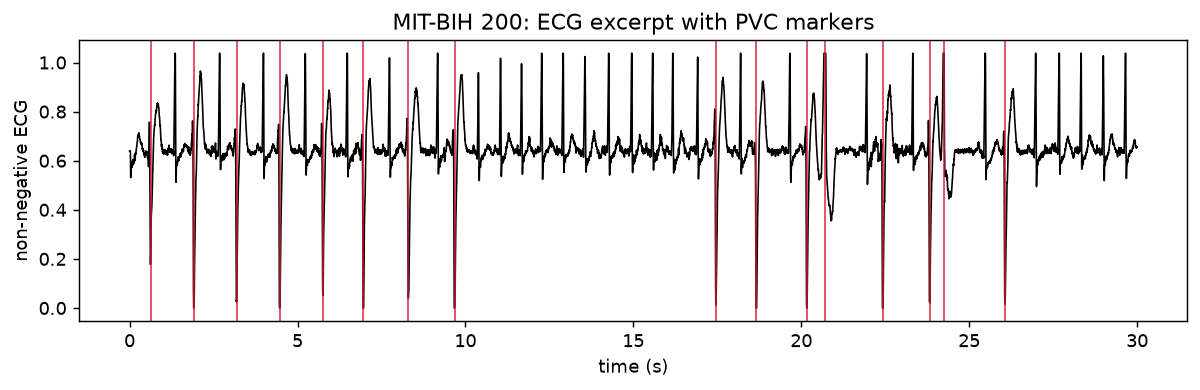

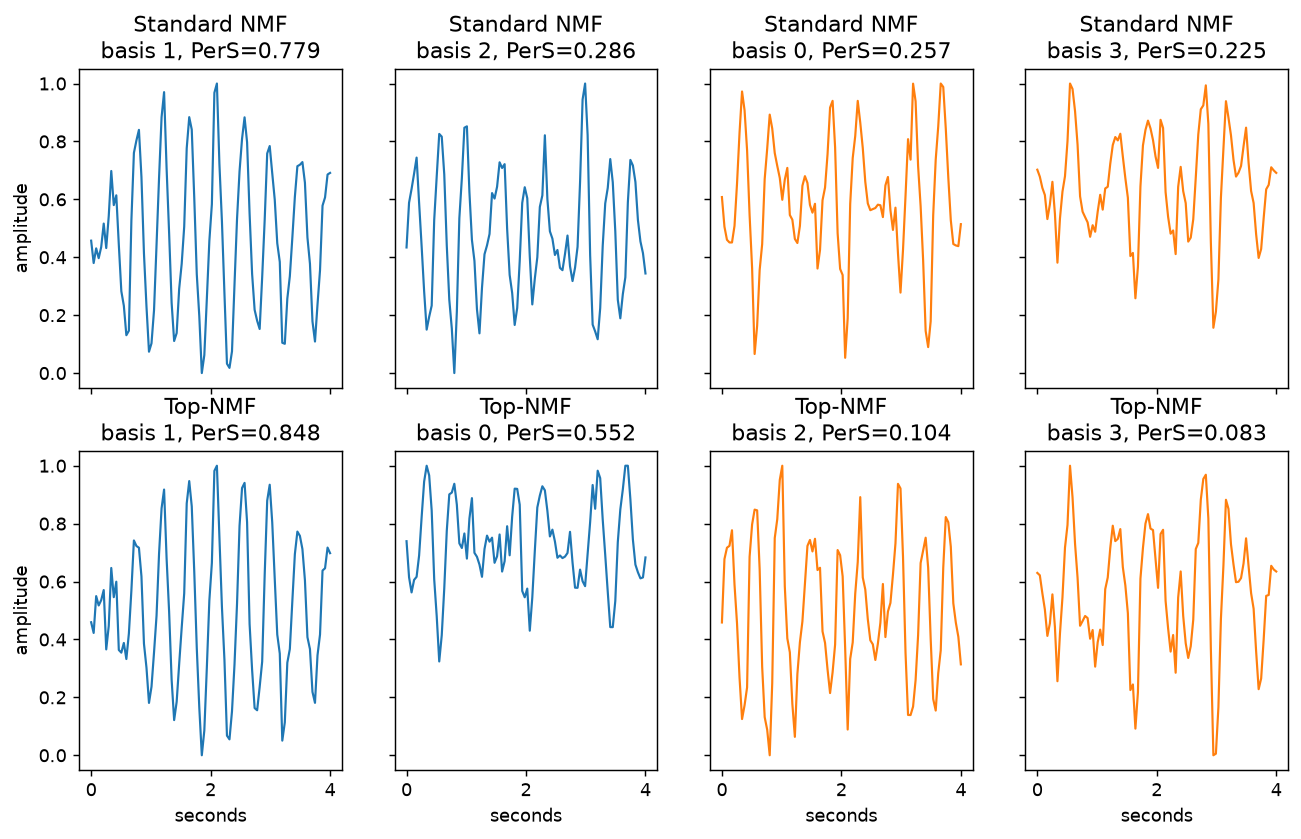

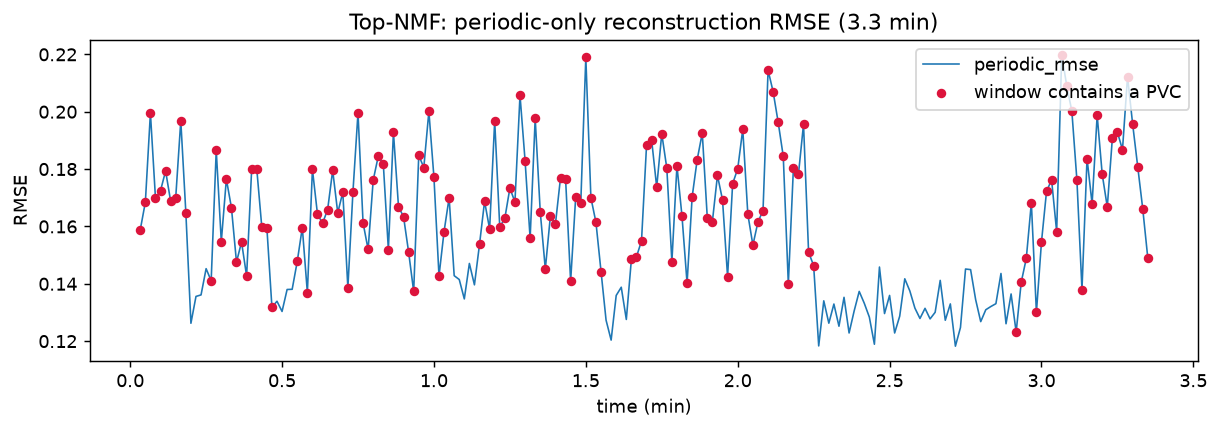

In [8]:
def plot_record_excerpt(record: ECGRecord, processed_signal: np.ndarray, start_sec: float, duration_sec: float) -> None:
    """Plot an ECG excerpt with PVC markers.

    Parameters
    ----------
    record : ECGRecord
        Loaded MIT-BIH record.
    processed_signal : np.ndarray
        Non-negative ECG signal.
    start_sec : float
        Start time in seconds.
    duration_sec : float
        Duration in seconds.

    Returns
    -------
    None
        Displays and saves a figure.
    """
    fs = record.fs
    start = int(round(start_sec * fs))
    stop = min(processed_signal.size, start + int(round(duration_sec * fs)))
    t = np.arange(start, stop) / fs
    fig, ax = plt.subplots(figsize=(11, 2.8))
    ax.plot(t, processed_signal[start:stop], lw=0.9, color="black")
    mask = (record.ann_samples >= start) & (record.ann_samples < stop) & (record.ann_symbols == PVC_SYMBOL)
    for sample in record.ann_samples[mask]:
        ax.axvline(sample / fs, color="crimson", lw=1.0, alpha=0.8)
    ax.set_title(f"MIT-BIH {record.name}: ECG excerpt with PVC markers")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("non-negative ECG")
    fig.savefig(OUTPUT_DIR / "MITBIH_ecg_excerpt.pdf")
    show_figure(fig)


def plot_bases(basis_reports: dict[str, pd.DataFrame], n_periodic: int) -> None:
    """Plot basis rows sorted by periodicity score.

    Parameters
    ----------
    basis_reports : dict[str, pd.DataFrame]
        Method name to the per-basis report returned by
        :func:`evaluate_factorisation`.
    n_periodic : int
        Number of bases treated as periodic.

    Returns
    -------
    None
        Displays and saves a figure.
    """
    n_methods = len(basis_reports)
    n_components = len(next(iter(basis_reports.values())))
    fig, axes = plt.subplots(n_methods, n_components, figsize=(12, 3.5 * n_methods), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(n_methods, n_components)
    for row_idx, (method, report) in enumerate(basis_reports.items()):
        ordered = report.sort_values("periodicity", ascending=False)
        time = np.linspace(0.0, WINDOW_SEC, len(ordered.iloc[0]["basis"]))
        for col_idx, (basis_idx, row) in enumerate(ordered.iterrows()):
            ax = axes[row_idx, col_idx]
            color = "tab:blue" if col_idx < n_periodic else "tab:orange"
            ax.plot(time, row["basis"], color=color, lw=1.2)
            ax.set_title(f"{method}\nbasis {basis_idx}, PerS={row['periodicity']:.3f}")
            if row_idx == n_methods - 1:
                ax.set_xlabel("seconds")
            if col_idx == 0:
                ax.set_ylabel("amplitude")
    fig.savefig(OUTPUT_DIR / "MITBIH_periodic_bases.pdf")
    show_figure(fig)


def plot_anomaly_timeline(meta: pd.DataFrame, scores: pd.DataFrame, method: str, n_windows: int = 200) -> None:
    """Plot the periodic-only reconstruction error over time with PVC markers.

    Parameters
    ----------
    meta : pd.DataFrame
        Window metadata.
    scores : pd.DataFrame
        Per-window score table.
    method : str
        Method name used in the title and filename.
    n_windows : int
        Number of leading windows to plot.

    Returns
    -------
    None
        Displays and saves a figure.
    """
    window = slice(0, n_windows)
    t = meta["center_sec"].to_numpy()[window] / 60.0
    is_pvc = meta["pvc_window"].to_numpy(dtype=bool)[window]
    y = scores["periodic_rmse"].to_numpy()[window]
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(t, y, color="tab:blue", lw=0.9, label="periodic_rmse")
    ax.scatter(t[is_pvc], y[is_pvc], s=18, color="crimson", label="window contains a PVC", zorder=3)
    ax.set_title(f"{method}: periodic-only reconstruction RMSE ({t[-1] - t[0]:.1f} min)")
    ax.set_xlabel("time (min)")
    ax.set_ylabel("RMSE")
    ax.legend(loc="upper right")
    safe_method = method.lower().replace(" ", "_").replace("-", "")
    fig.savefig(OUTPUT_DIR / f"MITBIH_{safe_method}_anomaly_timeline.pdf")
    show_figure(fig)


first_pvc = window_meta.loc[window_meta["pvc_window"], "center_sec"].min()
excerpt_start = 0.0 if pd.isna(first_pvc) else max(0.0, float(first_pvc) - 10.0)
plot_record_excerpt(record, processed, start_sec=excerpt_start, duration_sec=30.0)
plot_bases({"Standard NMF": std_bases, "Top-NMF": top_bases}, PERIODIC_COMPONENTS)
plot_anomaly_timeline(window_meta, top_scores, "Top-NMF")

In [9]:
def save_metric_tables(metric_table: pd.DataFrame, detection_table: pd.DataFrame) -> None:
    """Save metric tables for paper drafting.

    Parameters
    ----------
    metric_table : pd.DataFrame
        Factorisation metric table.
    detection_table : pd.DataFrame
        PVC detection metric table.

    Returns
    -------
    None
        Writes CSV files under ``OUTPUT_DIR``. Copy them, together with the
        generated PDFs, into ``paper/Figures/`` to update the manuscript.
    """
    metric_table.to_csv(OUTPUT_DIR / "MITBIH_factorisation_metrics.csv")
    detection_table.to_csv(OUTPUT_DIR / "MITBIH_pvc_detection_metrics.csv")


save_metric_tables(metric_table, detection_table)
print(f"Saved figures and tables under: {OUTPUT_DIR}")

Saved figures and tables under: /Users/kaji/Library/CloudStorage/Dropbox/maple/TopNMF/notebook/output
